# Stanford Solar Forecasting Dataset

This notebook downloads the **2017-2019 Images & PV Processed Dataset** (`2017_2019_images_pv_processed.hdf5`) and the corresponding timestamp arrays (`times_trainval.npy`, `times_test.npy`) from the Stanford Digital Repository.

**Dataset URL:** `https://stacks.stanford.edu/file/dj417rh1007/2017_2019_images_pv_processed.hdf5`


In [2]:
import os
# Ensure working directory is set to Colab's fast local storage
%cd /content

# Force unmount broken Drive mount if needed
!fusermount -u /content/drive 2>/dev/null || true

/content


## 1. Download Dataset to Fast Local Colab Disk (Recommended)

> **Best Practice:** Download directly to Colab's local NVMe disk (`/content/data/`). Downloading multi-gigabyte files directly over Google Drive's FUSE file system causes connection drops ("Transport endpoint is not connected").


In [ ]:
# IN THIS NOTEBOOK, WE ARE NOT REQUIRING THE TIMES, WE JUST UPLOADED TO THE GOOGLE DRIVE FOR FUTURE REFERENCE
!mkdir -p /content/data
!wget -c "https://stacks.stanford.edu/file/dj417rh1007/2017_2019_images_pv_processed.hdf5" -P /content/data/
!wget -c "https://stacks.stanford.edu/file/dj417rh1007/times_trainval.npy" -P /content/data/
!wget -c "https://stacks.stanford.edu/file/dj417rh1007/times_test.npy" -P /content/data/

--2026-09-03 21:25:38--  https://stacks.stanford.edu/file/dj417rh1007/2017_2019_images_pv_processed.hdf5
Resolving stacks.stanford.edu (stacks.stanford.edu)... 171.67.37.91
Connecting to stacks.stanford.edu (stacks.stanford.edu)|171.67.37.91|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-09-03 21:25:39--  https://stacks.stanford.edu/file/dj417rh1007/times_trainval.npy
Resolving stacks.stanford.edu (stacks.stanford.edu)... 171.67.37.91
Connecting to stacks.stanford.edu (stacks.stanford.edu)|171.67.37.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/octet-stream]
Saving to: ‘/content/data/times_trainval.npy’

times_trainval.npy      [     <=>            ]  10.33M  10.5MB/s    in 1.0s    

2026-09-03 21:25:40 (10.5 MB/s) - ‘/content/data/times_trainval.npy’ saved [10830814]

--2026-09-03 21:25:40--  https://stacks.stanford.ed

## 2. Verify Downloaded File

Check that the `.hdf5` file was downloaded completely and verify its size.


In [4]:
!ls -lh /content/data/

total 4.2G
-rw------- 1 root root 4.2G Sep  3 20:07 2017_2019_images_pv_processed.hdf5
drwxr-xr-x 2 root root 4.0K Sep  3 20:12 extracted
-rw-r--r-- 1 root root 424K Jun 22  2022 times_test.npy
-rw-r--r-- 1 root root  11M Jun 22  2022 times_trainval.npy


## 3 (a). (Optional) Backup Dataset to Google Drive

Once downloaded to local storage, you can safely copy the file to your Google Drive for permanent storage.


In [5]:
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/solar_data

Mounted at /content/drive


In [ ]:
!cp /content/data/2017_2019_images_pv_processed.hdf5 /content/drive/MyDrive/solar_data/
!cp /content/data/times_trainval.npy /content/drive/MyDrive/solar_data/ 2>/dev/null || true
!cp /content/data/times_test.npy /content/drive/MyDrive/solar_data/ 2>/dev/null || true

In [8]:
!ls -lh /content/drive/MyDrive/solar_data/

total 4.2G
-rw------- 1 root root 4.2G Sep  3 18:25 2017_2019_images_pv_processed.hdf5
-rw------- 1 root root 424K Sep  3 21:26 times_test.npy
-rw------- 1 root root  11M Sep  3 21:26 times_trainval.npy


## 3 (b). (Optional) Load Dataset from Google Drive to Local Colab Session


In [9]:
from google.colab import drive
import os

# 1. Mount Google Drive if not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# 2. Ensure local data directory exists
!mkdir -p /content/data

# 3. Copy the dataset and timestamps from Drive to fast local storage
!cp /content/drive/MyDrive/solar_data/2017_2019_images_pv_processed.hdf5 /content/data/
!cp /content/drive/MyDrive/solar_data/times_trainval.npy /content/data/ 2>/dev/null || true
!cp /content/drive/MyDrive/solar_data/times_test.npy /content/data/ 2>/dev/null || true

# 4. Verify that files were copied successfully
!ls -lh /content/data/

total 4.2G
-rw------- 1 root root 4.2G Sep  3 21:27 2017_2019_images_pv_processed.hdf5
drwxr-xr-x 2 root root 4.0K Sep  3 20:12 extracted
-rw-r--r-- 1 root root 424K Sep  3 21:27 times_test.npy
-rw-r--r-- 1 root root  11M Sep  3 21:27 times_trainval.npy


## 4. Unzip / Extract the Data


In [10]:
import h5py

file_path = "/content/data/2017_2019_images_pv_processed.hdf5"


def inspect_tree(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(
            f"Dataset: {name:<35} | "
            f"Shape: {str(obj.shape):<20} | "
            f"Dtype: {obj.dtype}"
        )
    elif isinstance(obj, h5py.Group):
        print(f"Group:   {name}")


with h5py.File(file_path, "r") as f:
    print("=" * 70)
    print("INTERNAL HDF5 TREE & DATASETS")
    print("=" * 70)

    f.visititems(inspect_tree)

INTERNAL HDF5 TREE & DATASETS
Group:   test
Dataset: test/images_log                     | Shape: (14003, 64, 64, 3)   | Dtype: uint8
Dataset: test/pv_log                         | Shape: (14003,)             | Dtype: float64
Group:   trainval
Dataset: trainval/images_log                 | Shape: (349372, 64, 64, 3)  | Dtype: uint8
Dataset: trainval/pv_log                     | Shape: (349372,)            | Dtype: float64


In [11]:
import h5py
import numpy as np
import os

file_path = "/content/data/2017_2019_images_pv_processed.hdf5"
output_dir = "/content/data/extracted/"

os.makedirs(output_dir, exist_ok=True)

with h5py.File(file_path, "r") as f:
    def extract_datasets(name, obj):
        if isinstance(obj, h5py.Dataset):
            # Replace / with _ for filename
            # e.g. trainval/images_log -> trainval_images_log.npy
            clean_name = name.replace("/", "_")
            save_path = os.path.join(output_dir, f"{clean_name}.npy")

            print(
                f"Extracting '{name}' "
                f"(Shape: {obj.shape}, Dtype: {obj.dtype}) ..."
            )

            np.save(save_path, np.array(obj))

    f.visititems(extract_datasets)

# Copy timestamp arrays to extracted directory if available
for t_file in ["times_trainval.npy", "times_test.npy"]:
    src_p = os.path.join("/content/data", t_file)
    if os.path.exists(src_p):
        np.save(os.path.join(output_dir, t_file), np.load(src_p, allow_pickle=True))

print("\nAll datasets extracted successfully!")

!ls -lh /content/data/extracted/

Extracting 'test/images_log' (Shape: (14003, 64, 64, 3), Dtype: uint8) ...
Extracting 'test/pv_log' (Shape: (14003,), Dtype: float64) ...
Extracting 'trainval/images_log' (Shape: (349372, 64, 64, 3), Dtype: uint8) ...
Extracting 'trainval/pv_log' (Shape: (349372,), Dtype: float64) ...

All datasets extracted successfully!
total 4.2G
-rw-r--r-- 1 root root 165M Sep  3 21:27 test_images_log.npy
-rw-r--r-- 1 root root 110K Sep  3 21:27 test_pv_log.npy
-rw-r--r-- 1 root root 261K Sep  3 21:32 times_test.npy
-rw-r--r-- 1 root root 6.4M Sep  3 21:32 times_trainval.npy
-rw-r--r-- 1 root root 4.0G Sep  3 21:30 trainval_images_log.npy
-rw-r--r-- 1 root root 2.7M Sep  3 21:32 trainval_pv_log.npy


## 5. Showing & Visualizing the Data


### 5.1 Load Data & Print Summary Statistics

We use `mmap_mode='r'` to memory-map the 4.0 GB image file so it loads instantly without overflowing Colab RAM.


In [12]:
import numpy as np
import pandas as pd
import os

data_dir = "/content/data/extracted/"

# Memory-map large files to save RAM
trainval_images = np.load(
    os.path.join(data_dir, "trainval_images_log.npy"), mmap_mode="r"
)
trainval_pv = np.load(os.path.join(data_dir, "trainval_pv_log.npy"))
test_images = np.load(os.path.join(data_dir, "test_images_log.npy"), mmap_mode="r")
test_pv = np.load(os.path.join(data_dir, "test_pv_log.npy"))

# Load timestamps (Option B: DateTime Index)
times_trainval_file = os.path.join(data_dir, "times_trainval.npy")
times_test_file = os.path.join(data_dir, "times_test.npy")

if not os.path.exists(times_trainval_file):
    times_trainval_file = "/content/data/times_trainval.npy"
if not os.path.exists(times_test_file):
    times_test_file = "/content/data/times_test.npy"

if os.path.exists(times_trainval_file):
    trainval_times = pd.to_datetime(np.load(times_trainval_file, allow_pickle=True))
    print(
        f"Loaded trainval_times: {len(trainval_times):,} timestamps ({trainval_times[0]} to {trainval_times[-1]})"
    )
else:
    trainval_times = None
    print("times_trainval.npy not found.")

if os.path.exists(times_test_file):
    test_times = pd.to_datetime(np.load(times_test_file, allow_pickle=True))
    print(
        f"Loaded test_times: {len(test_times):,} timestamps ({test_times[0]} to {test_times[-1]})"
    )
else:
    test_times = None
    print("times_test.npy not found.")

print("=" * 65)
print(f"{'DATASET':<25} | {'SHAPE':<18} | {'DTYPE':<10} | {'MIN / MAX'}")
print("=" * 65)
print(
    f"{'trainval_images_log':<25} | {str(trainval_images.shape):<18} | {str(trainval_images.dtype):<10} | {trainval_images[0].min():.2f} / {trainval_images[0].max():.2f}"
)
print(
    f"{'trainval_pv_log':<25} | {str(trainval_pv.shape):<18} | {str(trainval_pv.dtype):<10} | {trainval_pv.min():.4f} / {trainval_pv.max():.4f} kW"
)
print(
    f"{'test_images_log':<25} | {str(test_images.shape):<18} | {str(test_images.dtype):<10} | {test_images[0].min():.2f} / {test_images[0].max():.2f}"
)
print(
    f"{'test_pv_log':<25} | {str(test_pv.shape):<18} | {str(test_pv.dtype):<10} | {test_pv.min():.4f} / {test_pv.max():.4f} kW"
)
print("=" * 65)

Loaded trainval_times: 349,372 timestamps (2017-03-09 06:47:00 to 2019-10-26 17:59:20)
Loaded test_times: 14,003 timestamps (2017-09-15 07:11:00 to 2019-10-19 18:15:30)
DATASET                   | SHAPE              | DTYPE      | MIN / MAX
trainval_images_log       | (349372, 64, 64, 3) | uint8      | 1.00 / 255.00
trainval_pv_log           | (349372,)          | float64    | 0.0000 / 29.5854 kW
test_images_log           | (14003, 64, 64, 3) | uint8      | 0.00 / 255.00
test_pv_log               | (14003,)           | float64    | 0.0001 / 29.5709 kW


### 5.2 Random Sky Camera Fisheye Images (Train vs Test Samples)


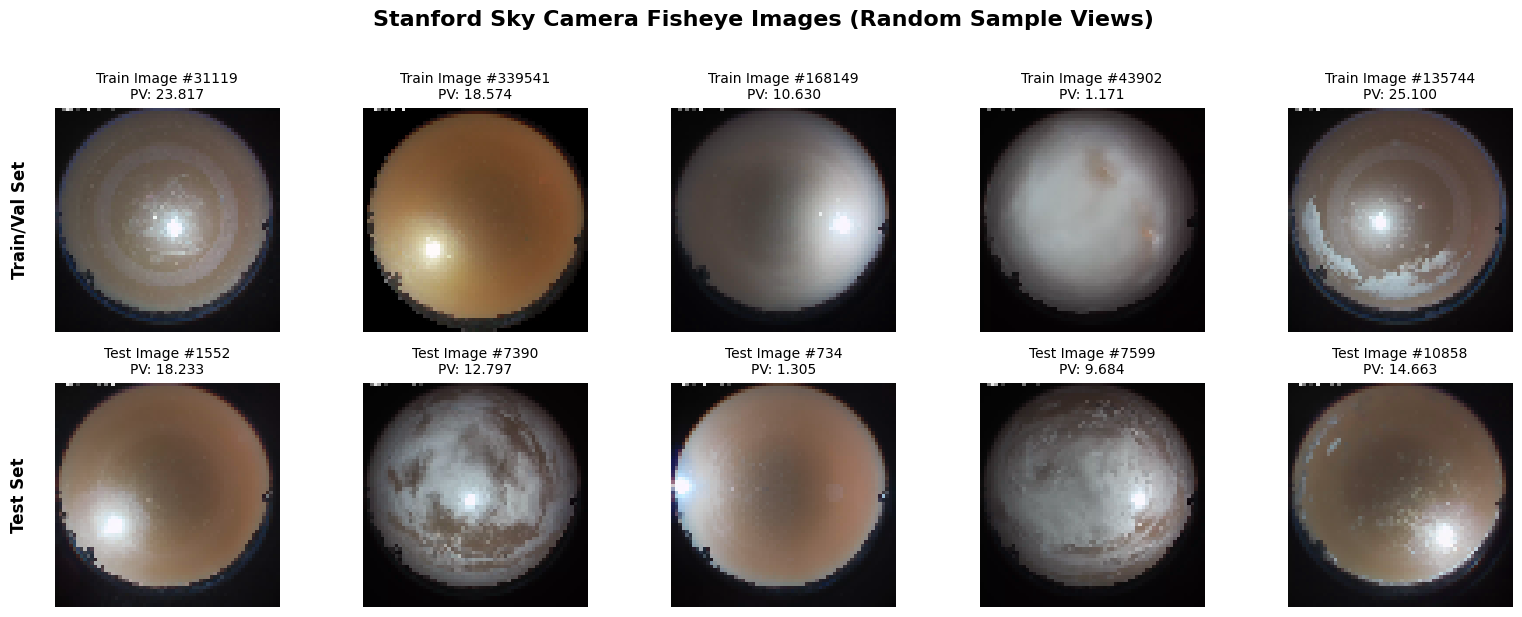

In [13]:
import matplotlib.pyplot as plt
import numpy as np


def format_img(img):
    if img.ndim == 3 and img.shape[0] == 3:
        img = np.transpose(img, (1, 2, 0))

    if img.max() > 1.0 and img.dtype != np.uint8:
        img = img / 255.0

    return img


fig, axes = plt.subplots(2, 5, figsize=(16, 6))

fig.suptitle(
    "Stanford Sky Camera Fisheye Images (Random Sample Views)",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

# Randomly select 5 training images
train_indices = np.random.choice(len(trainval_images), size=5, replace=False)

for i, idx in enumerate(train_indices):
    axes[0, i].imshow(format_img(trainval_images[idx]))
    axes[0, i].set_title(f"Train Image #{idx}\nPV: {trainval_pv[idx]:.3f}", fontsize=10)
    axes[0, i].axis("off")

axes[0, 0].text(
    -0.2,
    0.5,
    "Train/Val Set",
    transform=axes[0, 0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="center",
    rotation="vertical",
)


# Randomly select 5 test images
test_indices = np.random.choice(len(test_images), size=5, replace=False)

for i, idx in enumerate(test_indices):
    axes[1, i].imshow(format_img(test_images[idx]))
    axes[1, i].set_title(f"Test Image #{idx}\nPV: {test_pv[idx]:.3f}", fontsize=10)
    axes[1, i].axis("off")

axes[1, 0].text(
    -0.2,
    0.5,
    "Test Set",
    transform=axes[1, 0].transAxes,
    fontsize=12,
    fontweight="bold",
    va="center",
    rotation="vertical",
)

plt.tight_layout()
plt.show()

### 5.3 Random PV Power Time-Series (Minutes Scale) & Distribution Plots


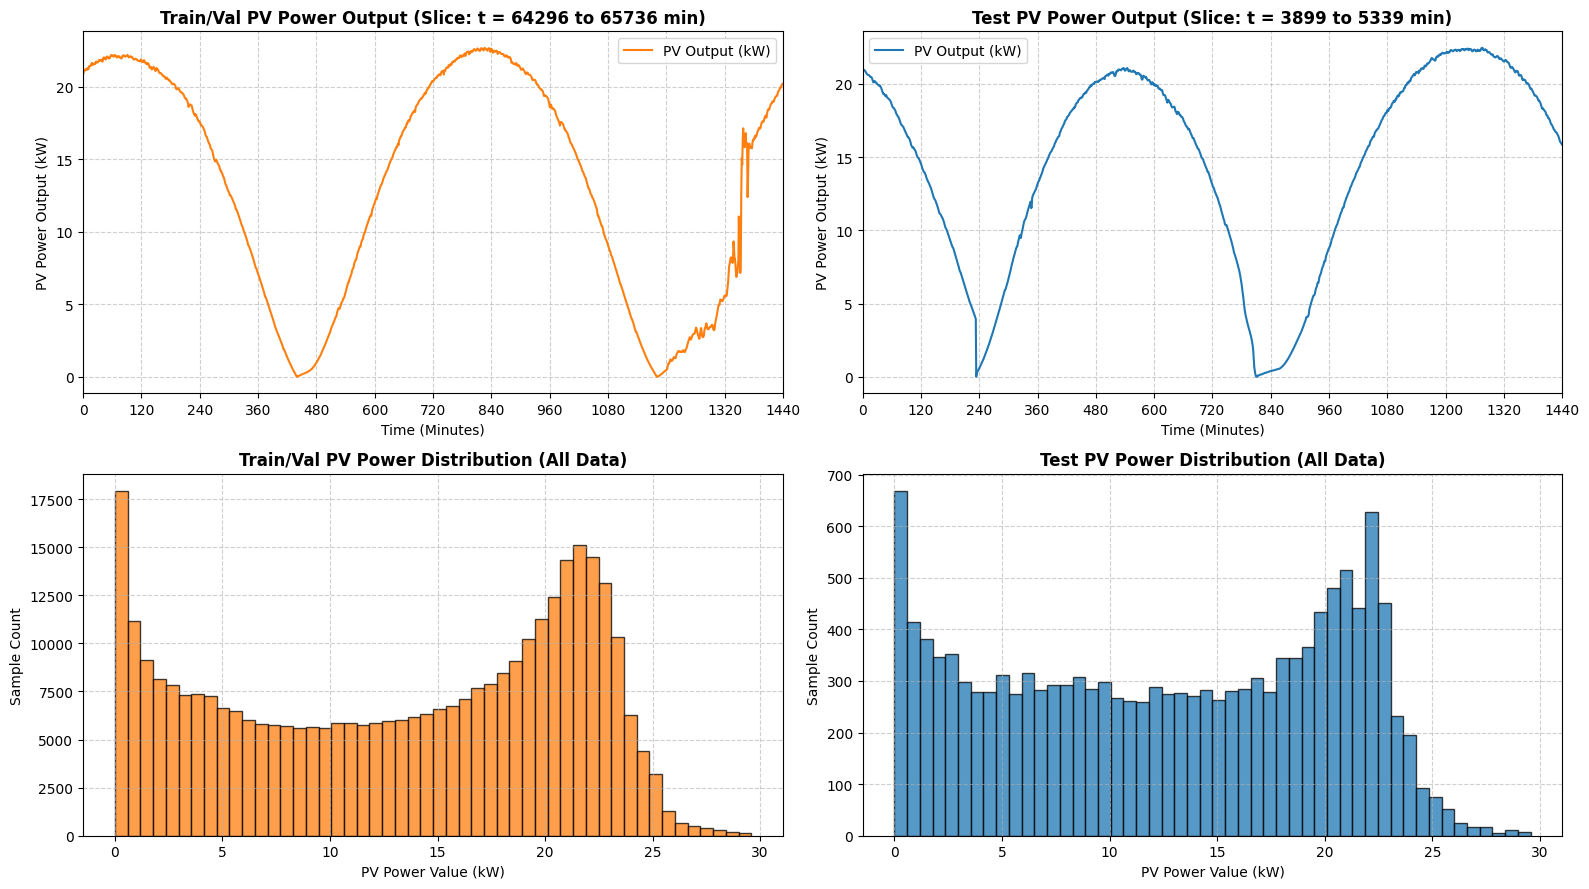

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Number of consecutive 1-minute samples to visualize (1440 min = 24 hours of daytime data)
slice_len = 1440
time_minutes = np.arange(slice_len)

# Randomly select valid starting indices
start_idx_train = np.random.randint(0, len(trainval_pv) - slice_len)
start_idx_test = np.random.randint(0, len(test_pv) - slice_len)

# Extract sample slices
trainval_sample_day = trainval_pv[start_idx_train : start_idx_train + slice_len]
test_sample_day = test_pv[start_idx_test : start_idx_test + slice_len]

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# 1. Train/Val PV Time Series (Minutes Scale)
axes[0, 0].plot(
    time_minutes,
    trainval_sample_day,
    color="tab:orange",
    linewidth=1.5,
    label="PV Output (kW)",
)
axes[0, 0].set_title(
    f"Train/Val PV Power Output (Slice: t = {start_idx_train} to {start_idx_train + slice_len} min)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 0].set_xlabel("Time (Minutes)", fontsize=10)
axes[0, 0].set_ylabel("PV Power Output (kW)", fontsize=10)
axes[0, 0].set_xlim(0, slice_len)
axes[0, 0].set_xticks(np.arange(0, slice_len + 1, 120))
axes[0, 0].grid(True, linestyle="--", alpha=0.6)
axes[0, 0].legend()

# 2. Test PV Time Series (Minutes Scale - No Dates)
axes[0, 1].plot(
    time_minutes,
    test_sample_day,
    color="tab:blue",
    linewidth=1.5,
    label="PV Output (kW)",
)
axes[0, 1].set_title(
    f"Test PV Power Output (Slice: t = {start_idx_test} to {start_idx_test + slice_len} min)",
    fontsize=12,
    fontweight="bold",
)
axes[0, 1].set_xlabel("Time (Minutes)", fontsize=10)
axes[0, 1].set_ylabel("PV Power Output (kW)", fontsize=10)
axes[0, 1].set_xlim(0, slice_len)
axes[0, 1].set_xticks(np.arange(0, slice_len + 1, 120))
axes[0, 1].grid(True, linestyle="--", alpha=0.6)
axes[0, 1].legend()

# 3. Train/Val PV Value Distribution (All Data)
axes[1, 0].hist(
    trainval_pv,
    bins=50,
    color="tab:orange",
    alpha=0.75,
    edgecolor="black",
)
axes[1, 0].set_title(
    "Train/Val PV Power Distribution (All Data)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 0].set_xlabel("PV Power Value (kW)", fontsize=10)
axes[1, 0].set_ylabel("Sample Count", fontsize=10)
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Test PV Value Distribution (All Data)
axes[1, 1].hist(
    test_pv,
    bins=50,
    color="tab:blue",
    alpha=0.75,
    edgecolor="black",
)
axes[1, 1].set_title(
    "Test PV Power Distribution (All Data)",
    fontsize=12,
    fontweight="bold",
)
axes[1, 1].set_xlabel("PV Power Value (kW)", fontsize=10)
axes[1, 1].set_ylabel("Sample Count", fontsize=10)
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### 5.4 Random Multimodal Alignment (Sky Image vs Corresponding Solar Generation)


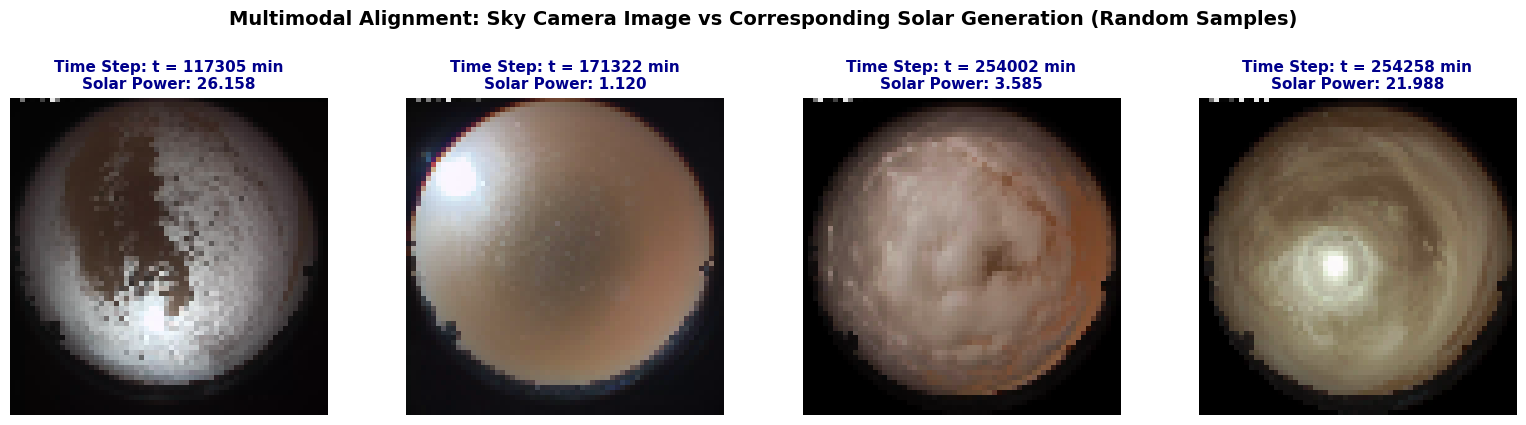

In [30]:
# Randomly select 4 distinct timesteps to visualize cloud cover vs output
indices = np.sort(np.random.choice(len(trainval_images), size=4, replace=False))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    "Multimodal Alignment: Sky Camera Image vs Corresponding Solar Generation (Random Samples)",
    fontsize=14,
    fontweight="bold",
    y=1.05,
)

for i, idx in enumerate(indices):
    axes[i].imshow(format_img(trainval_images[idx]))
    power_val = float(trainval_pv[idx])
    axes[i].set_title(
        f"Time Step: t = {idx} min\nSolar Power: {power_val:.3f}",
        fontsize=11,
        fontweight="bold",
        color="darkblue",
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 6. Remove Fisheye Distortion (Defisheye Transformation)

Ground-based sky cameras use hemispherical fisheye lenses with an equidistant projection ($r = f \cdot \theta$). While this captures a wide 180° field of view (FOV), it causes severe radial distortion where clouds and objects near the horizon appear compressed and warped.

In this section, we unwarp the fisheye distortion to a **rectilinear (perspective) planar projection**, process the entire dataset (both **Train/Val** and **Test** sets), and visualize the before-and-after results.


In [26]:
import cv2
import numpy as np
import os


def build_defisheye_maps(img_size=64, fov_deg=180.0, scale=1.0):
    """Precomputes (map_x, map_y) coordinate grids for converting equidistant
    fisheye sky camera images to a rectilinear (perspective) projection.

    img_size: int (image dimension, 64x64) fov_deg: Total Field of View in
    degrees (180 deg for hemispherical sky camera) scale: zoom / coverage scale
    factor
    """
    H, W = img_size, img_size
    cx, cy = (W - 1.0) / 2.0, (H - 1.0) / 2.0
    R_max = min(cx, cy)

    # Destination rectilinear coordinate grid [-1, 1]
    y_indices, x_indices = np.indices((H, W), dtype=np.float32)
    x_norm = (x_indices - cx) / (R_max * scale)
    y_norm = (y_indices - cy) / (R_max * scale)

    # Radial distance in rectilinear plane
    r_rect = np.sqrt(x_norm**2 + y_norm**2)

    # Angular distance theta from optical axis (zenith)
    theta = np.arctan(r_rect)

    # Corresponding radius in equidistant fisheye: r_fish = theta / (FOV / 2)
    fov_rad = np.deg2rad(fov_deg)
    r_fish = theta / (fov_rad / 2.0)

    # Scaling factor for remap coordinates
    with np.errstate(divide="ignore", invalid="ignore"):
        scale_factor = np.where(r_rect > 0, (r_fish / r_rect) * R_max, 0.0)

    map_x = cx + x_norm * scale_factor
    map_y = cy + y_norm * scale_factor

    # Mask out coordinates outside valid camera field of view
    valid_mask = (
        (theta <= fov_rad / 2.0)
        & (map_x >= 0)
        & (map_x <= W - 1)
        & (map_y >= 0)
        & (map_y <= H - 1)
    )

    map_x = np.where(valid_mask, map_x, -1.0).astype(np.float32)
    map_y = np.where(valid_mask, map_y, -1.0).astype(np.float32)

    return map_x, map_y


# Precompute 64x64 defisheye coordinate maps
map_x, map_y = build_defisheye_maps(img_size=64, fov_deg=180.0, scale=1.0)
print("Defisheye coordinate remapping grids precomputed successfully!")

Defisheye coordinate remapping grids precomputed successfully!


### 6.2 Remove Fisheye Distortion Across Whole Dataset (Train/Val & Test)

We process the dataset in memory-mapped streaming batches so it runs efficiently without overflowing RAM.


In [27]:
def defisheye_dataset(input_array, output_path, map_x, map_y, batch_size=10000):
    """Applies defisheye unwarping to an entire dataset array and saves to a
    memory-mapped .npy file on disk.
    """
    N, H, W, C = input_array.shape
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Create memory-mapped file on disk to conserve RAM
    out_mmap = np.lib.format.open_memmap(
        output_path,
        mode="w+",
        dtype=input_array.dtype,
        shape=(N, H, W, C),
    )

    print(f"Processing {N:,} images ({input_array.dtype}) in batches of {batch_size:,}...")

    for start_idx in range(0, N, batch_size):
        end_idx = min(start_idx + batch_size, N)
        batch = input_array[start_idx:end_idx]

        for i in range(len(batch)):
            out_mmap[start_idx + i] = cv2.remap(
                batch[i],
                map_x,
                map_y,
                interpolation=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_CONSTANT,
                borderValue=0,
            )

        if (end_idx % 50000 == 0) or (end_idx == N):
            print(f"  Progress: {end_idx:,} / {N:,} images ({end_idx / N * 100:.1f}%)")
            out_mmap.flush()

    print(f"Completed! Saved to: {output_path}\n")
    return out_mmap


data_dir = "/content/data/extracted/"
trainval_defisheye_path = os.path.join(data_dir, "trainval_images_defisheye.npy")
test_defisheye_path = os.path.join(data_dir, "test_images_defisheye.npy")

# 1. Process Train/Val Dataset (349,372 images)
print("=" * 65)
print("PROCESSING TRAIN/VAL SET")
print("=" * 65)
trainval_images_defisheye = defisheye_dataset(
    trainval_images, trainval_defisheye_path, map_x, map_y, batch_size=10000
)

# 2. Process Test Dataset (14,003 images)
print("=" * 65)
print("PROCESSING TEST SET")
print("=" * 65)
test_images_defisheye = defisheye_dataset(
    test_images, test_defisheye_path, map_x, map_y, batch_size=5000
)

!ls -lh /content/data/extracted/*defisheye*


PROCESSING TRAIN/VAL SET
Processing 349,372 images (uint8) in batches of 10,000...
  Progress: 50,000 / 349,372 images (14.3%)
  Progress: 100,000 / 349,372 images (28.6%)
  Progress: 150,000 / 349,372 images (42.9%)
  Progress: 200,000 / 349,372 images (57.2%)
  Progress: 250,000 / 349,372 images (71.6%)
  Progress: 300,000 / 349,372 images (85.9%)
  Progress: 349,372 / 349,372 images (100.0%)
Completed! Saved to: /content/data/extracted/trainval_images_defisheye.npy

PROCESSING TEST SET
Processing 14,003 images (uint8) in batches of 5,000...
  Progress: 14,003 / 14,003 images (100.0%)
Completed! Saved to: /content/data/extracted/test_images_defisheye.npy

-rw-r--r-- 1 root root 165M Sep  3 21:55 /content/data/extracted/test_images_defisheye.npy
-rw-r--r-- 1 root root 4.0G Sep  3 21:55 /content/data/extracted/trainval_images_defisheye.npy


### 6.3 Visualize Results: Fisheye (Original) vs Defisheye (Rectilinear)

Comparison of original fisheye images against undistorted rectilinear images for random samples across both the **Train/Val** and **Test** sets.


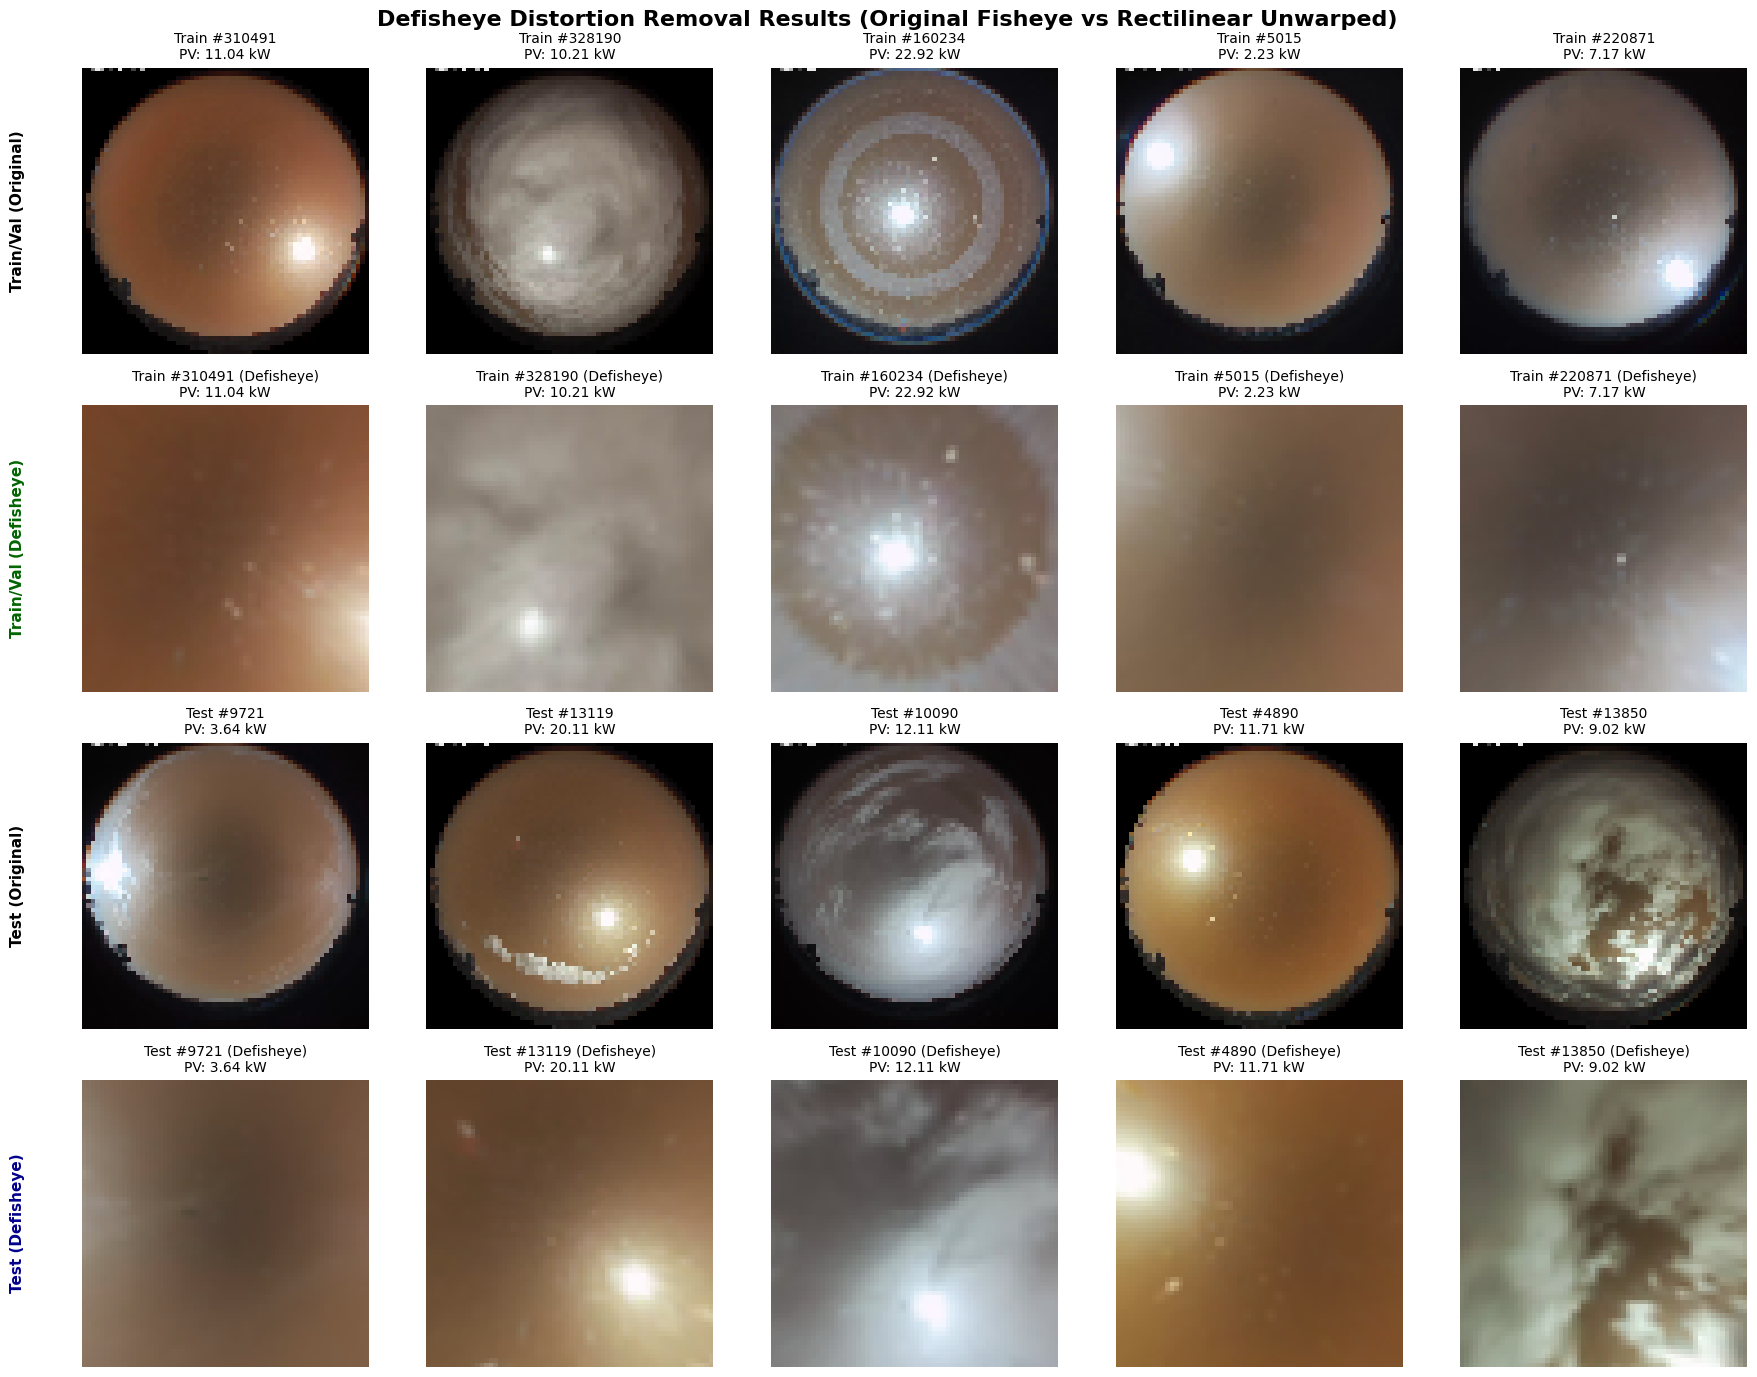

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Select 5 random samples from Train/Val and 5 from Test
np.random.seed(42)
train_indices = np.random.choice(len(trainval_images), size=5, replace=False)
test_indices = np.random.choice(len(test_images), size=5, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(18, 14))

fig.suptitle(
    "Defisheye Distortion Removal Results (Original Fisheye vs Rectilinear Unwarped)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# Row 1: Train/Val Original Fisheye
for i, idx in enumerate(train_indices):
    axes[0, i].imshow(format_img(trainval_images[idx]))
    axes[0, i].set_title(f"Train #{idx}\nPV: {trainval_pv[idx]:.2f} kW", fontsize=10)
    axes[0, i].axis("off")

axes[0, 0].text(
    -0.25,
    0.5,
    "Train/Val (Original)",
    transform=axes[0, 0].transAxes,
    fontsize=11,
    fontweight="bold",
    va="center",
    rotation="vertical",
)

# Row 2: Train/Val Defisheye
for i, idx in enumerate(train_indices):
    axes[1, i].imshow(format_img(trainval_images_defisheye[idx]))
    axes[1, i].set_title(
        f"Train #{idx} (Defisheye)\nPV: {trainval_pv[idx]:.2f} kW", fontsize=10
    )
    axes[1, i].axis("off")

axes[1, 0].text(
    -0.25,
    0.5,
    "Train/Val (Defisheye)",
    transform=axes[1, 0].transAxes,
    fontsize=11,
    fontweight="bold",
    va="center",
    color="darkgreen",
    rotation="vertical",
)

# Row 3: Test Original Fisheye
for i, idx in enumerate(test_indices):
    axes[2, i].imshow(format_img(test_images[idx]))
    axes[2, i].set_title(f"Test #{idx}\nPV: {test_pv[idx]:.2f} kW", fontsize=10)
    axes[2, i].axis("off")

axes[2, 0].text(
    -0.25,
    0.5,
    "Test (Original)",
    transform=axes[2, 0].transAxes,
    fontsize=11,
    fontweight="bold",
    va="center",
    rotation="vertical",
)

# Row 4: Test Defisheye
for i, idx in enumerate(test_indices):
    axes[3, i].imshow(format_img(test_images_defisheye[idx]))
    axes[3, i].set_title(
        f"Test #{idx} (Defisheye)\nPV: {test_pv[idx]:.2f} kW", fontsize=10
    )
    axes[3, i].axis("off")

axes[3, 0].text(
    -0.25,
    0.5,
    "Test (Defisheye)",
    transform=axes[3, 0].transAxes,
    fontsize=11,
    fontweight="bold",
    va="center",
    color="darkblue",
    rotation="vertical",
)

plt.tight_layout()
plt.show()

## 7. Package Defisheyed Dataset into HDF5 & Save to Google Drive

We package the preprocessed (defisheyed) sky images and corresponding PV power generation data into a new `.hdf5` file: **`2017_2019_images_pv_defisheye.hdf5`**.

This file retains the **exact same internal structure, groups, datasets, datatypes, and shapes** as the original Stanford SKIPP'D HDF5 file, making it a 100% drop-in replacement for all future modeling and forecasting notebooks.


In [29]:
import h5py
import numpy as np
import os

output_hdf5_path = "/content/data/2017_2019_images_pv_defisheye.hdf5"
data_dir = "/content/data/extracted/"

# Memory-map input arrays
trainval_defisheye_img = np.load(
    os.path.join(data_dir, "trainval_images_defisheye.npy"), mmap_mode="r"
)
trainval_pv = np.load(os.path.join(data_dir, "trainval_pv_log.npy"))
test_defisheye_img = np.load(
    os.path.join(data_dir, "test_images_defisheye.npy"), mmap_mode="r"
)
test_pv = np.load(os.path.join(data_dir, "test_pv_log.npy"))

print("=" * 70)
print(f"PACKAGING DEFISHEYED DATASET INTO: {output_hdf5_path}")
print("=" * 70)

batch_size = 10000

with h5py.File(output_hdf5_path, "w") as f:
    # 1. Group: trainval
    grp_tv = f.create_group("trainval")
    print(f"Writing trainval/images_log {trainval_defisheye_img.shape} ({trainval_defisheye_img.dtype}) ...")
    dset_tv_img = grp_tv.create_dataset(
        "images_log",
        shape=trainval_defisheye_img.shape,
        dtype=trainval_defisheye_img.dtype,
        chunks=(min(1000, len(trainval_defisheye_img)), 64, 64, 3),
    )
    for start_idx in range(0, len(trainval_defisheye_img), batch_size):
        end_idx = min(start_idx + batch_size, len(trainval_defisheye_img))
        dset_tv_img[start_idx:end_idx] = trainval_defisheye_img[start_idx:end_idx]
        if (end_idx % 50000 == 0) or (end_idx == len(trainval_defisheye_img)):
            print(f"  Progress: {end_idx:,} / {len(trainval_defisheye_img):,} images ({end_idx / len(trainval_defisheye_img) * 100:.1f}%)")

    print(f"Writing trainval/pv_log {trainval_pv.shape} ({trainval_pv.dtype}) ...")
    grp_tv.create_dataset("pv_log", data=trainval_pv, dtype=np.float64)

    # 2. Group: test
    grp_te = f.create_group("test")
    print(f"Writing test/images_log {test_defisheye_img.shape} ({test_defisheye_img.dtype}) ...")
    dset_te_img = grp_te.create_dataset(
        "images_log",
        shape=test_defisheye_img.shape,
        dtype=test_defisheye_img.dtype,
        chunks=(min(1000, len(test_defisheye_img)), 64, 64, 3),
    )
    for start_idx in range(0, len(test_defisheye_img), batch_size):
        end_idx = min(start_idx + batch_size, len(test_defisheye_img))
        dset_te_img[start_idx:end_idx] = test_defisheye_img[start_idx:end_idx]

    print(f"Writing test/pv_log {test_pv.shape} ({test_pv.dtype}) ...")
    grp_te.create_dataset("pv_log", data=test_pv, dtype=np.float64)

print("\nAll datasets packaged into HDF5 successfully!")
!ls -lh /content/data/2017_2019_images_pv_defisheye.hdf5

PACKAGING DEFISHEYED DATASET INTO: /content/data/2017_2019_images_pv_defisheye.hdf5
Writing trainval/images_log (349372, 64, 64, 3) (uint8) ...
  Progress: 50,000 / 349,372 images (14.3%)
  Progress: 100,000 / 349,372 images (28.6%)
  Progress: 150,000 / 349,372 images (42.9%)
  Progress: 200,000 / 349,372 images (57.2%)
  Progress: 250,000 / 349,372 images (71.6%)
  Progress: 300,000 / 349,372 images (85.9%)
  Progress: 349,372 / 349,372 images (100.0%)
Writing trainval/pv_log (349372,) (float64) ...
Writing test/images_log (14003, 64, 64, 3) (uint8) ...
Writing test/pv_log (14003,) (float64) ...

All datasets packaged into HDF5 successfully!
-rw-r--r-- 1 root root 4.2G Sep  3 22:00 /content/data/2017_2019_images_pv_defisheye.hdf5


### 7.2 Verify Internal HDF5 Tree Structure

Confirm that the internal structure matches the original dataset format.


In [30]:
import h5py

output_hdf5_path = "/content/data/2017_2019_images_pv_defisheye.hdf5"


def inspect_h5_tree(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(
            f"Dataset: {name:<35} | "
            f"Shape: {str(obj.shape):<20} | "
            f"Dtype: {obj.dtype}"
        )
    elif isinstance(obj, h5py.Group):
        print(f"Group:   {name}")


with h5py.File(output_hdf5_path, "r") as f:
    print("=" * 70)
    print("INTERNAL HDF5 TREE (DEFISHEYED DATASET)")
    print("=" * 70)
    f.visititems(inspect_h5_tree)
    print("=" * 70)

INTERNAL HDF5 TREE (DEFISHEYED DATASET)
Group:   test
Dataset: test/images_log                     | Shape: (14003, 64, 64, 3)   | Dtype: uint8
Dataset: test/pv_log                         | Shape: (14003,)             | Dtype: float64
Group:   trainval
Dataset: trainval/images_log                 | Shape: (349372, 64, 64, 3)  | Dtype: uint8
Dataset: trainval/pv_log                     | Shape: (349372,)            | Dtype: float64


### 7.3 Save Defisheyed Dataset & Timestamps to Google Drive for Permanent Storage

Copy the newly created `2017_2019_images_pv_defisheye.hdf5` and timestamp files to your Google Drive (`/content/drive/MyDrive/solar_data/`).


In [31]:
from google.colab import drive
import os

# 1. Ensure Drive is mounted
if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

# 2. Ensure target folder exists in Drive
!mkdir -p /content/drive/MyDrive/solar_data

# 3. Copy defisheyed HDF5 and timestamp arrays to Google Drive
print("Copying 2017_2019_images_pv_defisheye.hdf5 to Google Drive...")
!cp /content/data/2017_2019_images_pv_defisheye.hdf5 /content/drive/MyDrive/solar_data/
!cp /content/data/times_trainval.npy /content/drive/MyDrive/solar_data/ 2>/dev/null || true
!cp /content/data/times_test.npy /content/drive/MyDrive/solar_data/ 2>/dev/null || true

# 4. Verify saved files in Drive
print("\nFiles in Google Drive (/content/drive/MyDrive/solar_data/):")
!ls -lh /content/drive/MyDrive/solar_data/

Copying 2017_2019_images_pv_defisheye.hdf5 to Google Drive...

Files in Google Drive (/content/drive/MyDrive/solar_data/):
total 8.4G
-rw------- 1 root root 4.2G Sep  3 22:00 2017_2019_images_pv_defisheye.hdf5
-rw------- 1 root root 4.2G Sep  3 18:25 2017_2019_images_pv_processed.hdf5
-rw------- 1 root root 424K Sep  3 22:00 times_test.npy
-rw------- 1 root root  11M Sep  3 22:00 times_trainval.npy
